# <span style='color:Red'>Main effect analysis (graphs)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, os, pandas, re, ast, seaborn, jlib
from matplotlib import pyplot
from matplotlib import patches

saveFigs = True
imagePath = 'img/main/'
imageFormats = ['svg','pdf']
exportsPath = 'exports/'

minAccuracyValue = 0
maxAccuracyValue = 1.2

minErrorOverBlocksValue = 0
maxErrorOverBlocksValue = 70

minBaseErrorOverBlocksValue = -20
maxBaseErrorOverBlocksValue = 20

significanceSize = 14

desiredEffectSize = 'ges'

nBinsHist = 36

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}

coloursPath = '../../experiment3_EEG/StimResponse/Exp3_ColorSpace_6.csv'
colourCircleValues = numpy.genfromtxt(coloursPath,delimiter=',')

colourCircleValues = colourCircleValues[::int(colourCircleValues.shape[0]/360)]
colourCircleValues = (colourCircleValues+1)*0.5

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp3Values.csv")

allParticipantData = pandas.read_csv(exportsPath+'participantData_long_preEEG.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path'],axis=1,inplace=True)

## <span style='color:Red'>Results: Awareness</span>

### <span style='color:Red'>Distribution of awareness values</span>

In [2]:
# TBD

In [3]:
absErrData = allParticipantData.copy()
absErrData = absErrData.groupby(['Subject','Trial type']).median().reset_index()

accData = allParticipantData.copy()
accData = accData.groupby(['Subject','Trial type']).mean().reset_index()

## <span style='color:Red'>Results: continuous error (all subjects)</span>

### <span style='color:Red'>Error over blocks</span>

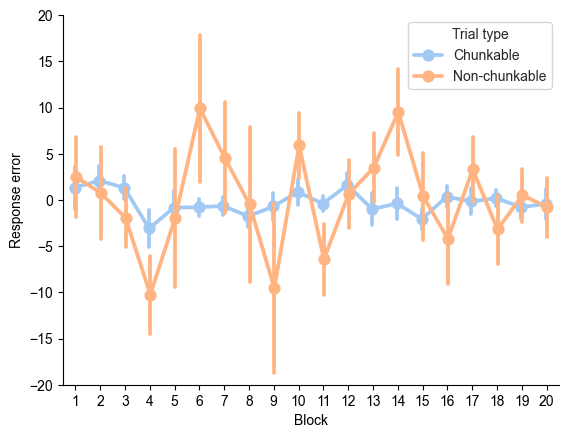

In [4]:
angleColumns = ['Response error']

errOverTime = allParticipantData.copy()
errOverTime = errOverTime.groupby(['Subject','Block','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

fig,ax = pyplot.subplots()
seaborn.set_style('ticks')
seaborn.pointplot(ax=ax,
                  data=errOverTime,
                  x='Block',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_ylim(minBaseErrorOverBlocksValue,maxBaseErrorOverBlocksValue)
seaborn.despine()

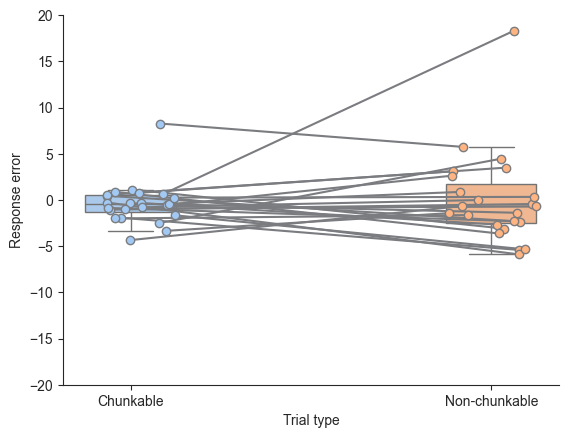

In [5]:
errMean = allParticipantData.copy()
errMean = errMean.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

fig,ax = pyplot.subplots()
seaborn.set_style('ticks')
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=errMean,
                                     x='Trial type',y='Response error',
                                     width=0.25,palette=paletteBase)
ax.set_ylim(minBaseErrorOverBlocksValue,maxBaseErrorOverBlocksValue)
seaborn.despine()

In [6]:
errNCTrial = errMean.loc[errMean['Trial type']=='Non-chunkable',:]['Response error'].to_numpy()
errCTrial = errMean.loc[errMean['Trial type']=='Chunkable',:]['Response error'].to_numpy()

errChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=errNCTrial,
                                                          column2=errCTrial,
                                                          isStudent=False,isWilcoxon=True,hypothesis='different',
                                                          effectSize=True,descriptives=True)

errChunkingTtestPS['ttest'].columns = errChunkingTtestPS['ttest'].columns.str.rstrip('[wilc]')

# mapValueHandler.setKeyValue("ttestPSErrChunkingEffect",
#                             jlib.data.constants.extractWilcoxonResults(errChunkingTtestPS['ttest'],0))

errChunkingTtestPS

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  133.0  0.893212   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation -0.036232  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.824099  0.000956,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23  0.082617 -0.703256  5.038376  1.050574
 "set21"  set2   23 -0.370128 -0.404120  2.335288  0.486941}

In [7]:
errChunkingTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          variables=[errCTrial,
                                                                     errNCTrial],
                                                          testValue=0,isStudent=False,isWilcoxon=True,hypothesis='gt',
                                                          effectSize=True,descriptives=True)

errChunkingTtestOS['ttest'].columns = errChunkingTtestOS['ttest'].columns.str.rstrip('[wilc]')

# mapValueHandler.setKeyValue("ttestOSerrTrialsChunkable",
#                             jlib.data.constants.extractWilcoxonResults(errChunkingTtestOS['ttest'],0,2))

# mapValueHandler.setKeyValue("ttestOSerrTrialsNonchunkable",
#                             jlib.data.constants.extractWilcoxonResults(errChunkingTtestOS['ttest'],1,2))

errChunkingTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W   85.0  0.947729  Rank biserial correlation -0.384058
 "set1"  set1  Wilcoxon W  112.0  0.786291  Rank biserial correlation -0.188406,
 'normality':         name         w         p
 "set0"  set0  0.789355  0.000260
 "set1"  set1  0.805434  0.000469,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23 -0.370128 -0.404120  2.335288  0.486941
 "set1"  set1   23  0.082617 -0.703256  5.038376  1.050574}

### <span style='color:Red'>Error distribution</span>

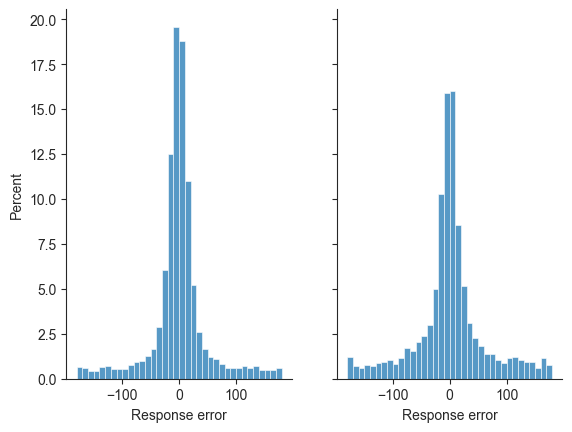

In [8]:
fig,ax = pyplot.subplots(1,2,sharey=True)
seaborn.set_style('ticks')
seaborn.histplot(ax=ax[0],data=allParticipantData[allParticipantData['Trial type']=='Chunkable'],
                 x="Response error",stat='percent',bins=nBinsHist)
seaborn.histplot(ax=ax[1],data=allParticipantData[allParticipantData['Trial type']=='Non-chunkable'],
                 x="Response error",stat='percent',bins=nBinsHist)
seaborn.despine()

### <span style='color:Red'>Response distribution on colorwheel</span>

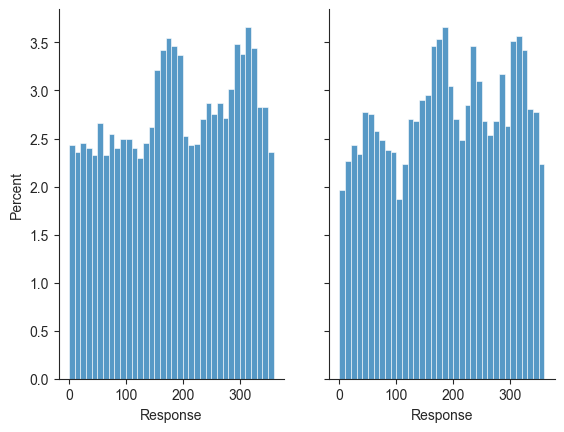

In [9]:
nbins = 36

responseData = allParticipantData.copy()
responseData['Response'] = responseData['Continuous target']*360/jlib.compression.constants.EXP4_RESPONSE_SECTIONS-responseData['Response error']
responseData['Response'] = responseData.apply(
    lambda x: numpy.arctan2(numpy.sin(x['Response']*numpy.pi/180),
                            numpy.cos(x['Response']*numpy.pi/180))*180/numpy.pi,axis=1)
responseData.loc[responseData['Response']<0,'Response'] += 360

fig,ax = pyplot.subplots(1,2,sharey=True)
seaborn.set_style('ticks')
seaborn.histplot(ax=ax[0],data=responseData[responseData['Trial type']=='Chunkable'],
                 x="Response",stat='percent',bins=nBinsHist)
seaborn.histplot(ax=ax[1],data=responseData[responseData['Trial type']=='Non-chunkable'],
                 x="Response",stat='percent',bins=nBinsHist)
seaborn.despine()

## <span style='color:Red'>Results: continuous error (absolute)</span>

### <span style='color:Red'>Error over blocks</span>

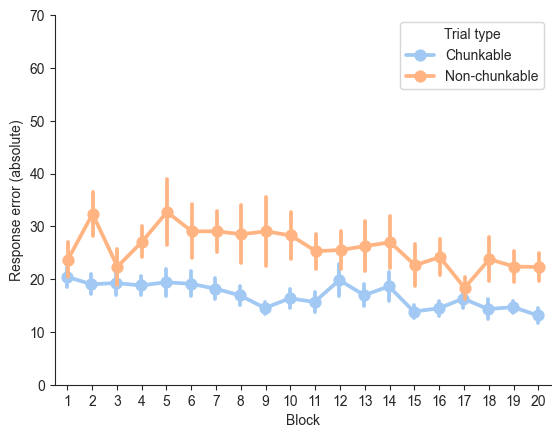

In [10]:
fig,ax = pyplot.subplots()
seaborn.set_style('ticks')
seaborn.pointplot(ax=ax,
                  data=allParticipantData.groupby(['Subject','Block',
                                                   'Trial type']).median().reset_index(),
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
seaborn.despine()

### <span style='color:Red'>Error distribution for each pair assignment</span>

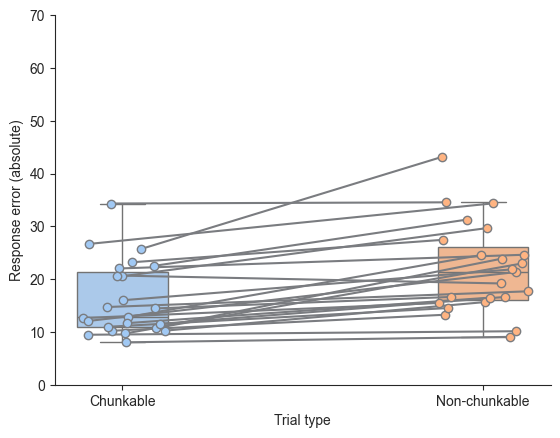

In [11]:
fig,ax = pyplot.subplots()
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=absErrData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax.set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
seaborn.despine()

In [12]:
absErrNCTrial = absErrData.loc[absErrData['Trial type']=='Non-chunkable',:]['Response error (absolute)'].to_numpy()
absErrCTrial = absErrData.loc[absErrData['Trial type']=='Chunkable',:]['Response error (absolute)'].to_numpy()

absErrChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                             column1=absErrNCTrial,
                                                             column2=absErrCTrial,
                                                             isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                             effectSize=True,descriptives=True)

absErrChunkingTtestPS['ttest'].columns = absErrChunkingTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSAbsErrChunkingEffect",
                            jlib.data.constants.extractTtestResults(absErrChunkingTtestPS['ttest'],0))

absErrChunkingTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  5.803003  22.0  0.000004   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.21001  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.943755  0.216219,
 'descriptives':          name  num          m        med        sd        se
 "set11"  set1   23  21.929655  21.338537  8.499175  1.772201
 "set21"  set2   23  16.128807  12.837422  6.944491  1.448027}

## <span style='color:Red'>Results: accuracy (all subjects)</span>

### <span style='color:Red'>Accuracy over blocks</span>

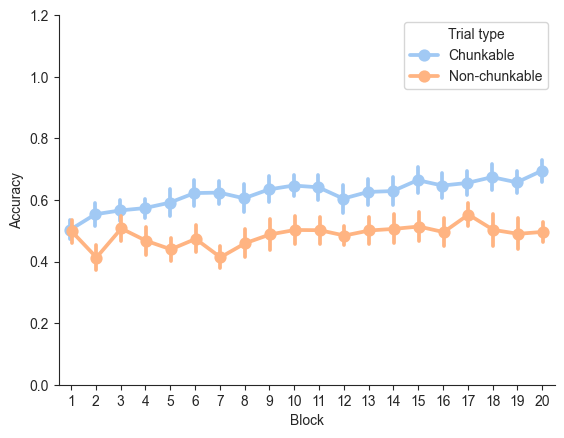

In [13]:
fig,ax = pyplot.subplots()
seaborn.set_style('ticks')
seaborn.pointplot(ax=ax,
                  data=allParticipantData.groupby(['Subject','Block',
                                                   'Trial type']).mean().reset_index(),
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_ylim(minAccuracyValue,maxAccuracyValue)
seaborn.despine()

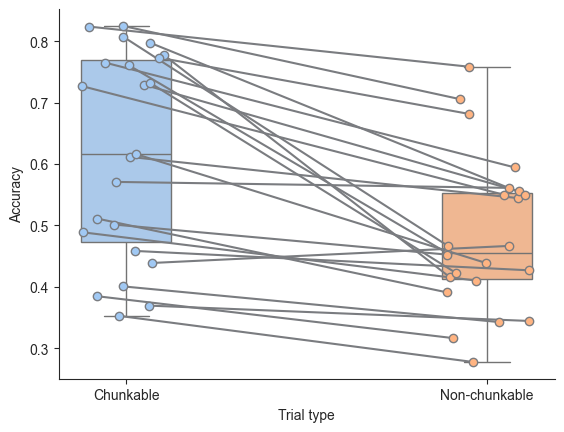

In [14]:
fig,ax = pyplot.subplots()
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=accData,
                                     x='Trial type',y='Accuracy',
                                     width=0.25,palette=paletteBase)
seaborn.despine()

In [15]:
accNCTrial = accData.loc[accData['Trial type']=='Non-chunkable',:]['Accuracy'].to_numpy()
accCTrial = accData.loc[accData['Trial type']=='Chunkable',:]['Accuracy'].to_numpy()

accChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=accCTrial,
                                                          column2=accNCTrial,
                                                          isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                          effectSize=True,descriptives=True)

accChunkingTtestPS['ttest'].columns = accChunkingTtestPS['ttest'].columns.str.rstrip('[wilc]')

# mapValueHandler.setKeyValue("ttestPSAccChunkingEffect",
#                             jlib.data.constants.extractWilcoxonResults(accChunkingTtestPS['ttest'],0))

accChunkingTtestPS

{'ttest':                            var1  var2        test   stat             p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  273.0  5.960464e-07   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.978261  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.908562  0.038099,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23  0.618302  0.616134  0.167421  0.034910
 "set21"  set2   23  0.483865  0.455556  0.124192  0.025896}

In [16]:
mapValueHandler.saveData()

All data saved correctly to exports/exp3Values.csv


## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>Absolute error/accuracy</span>

(0.0, 1.0, 0.0, 1.0)

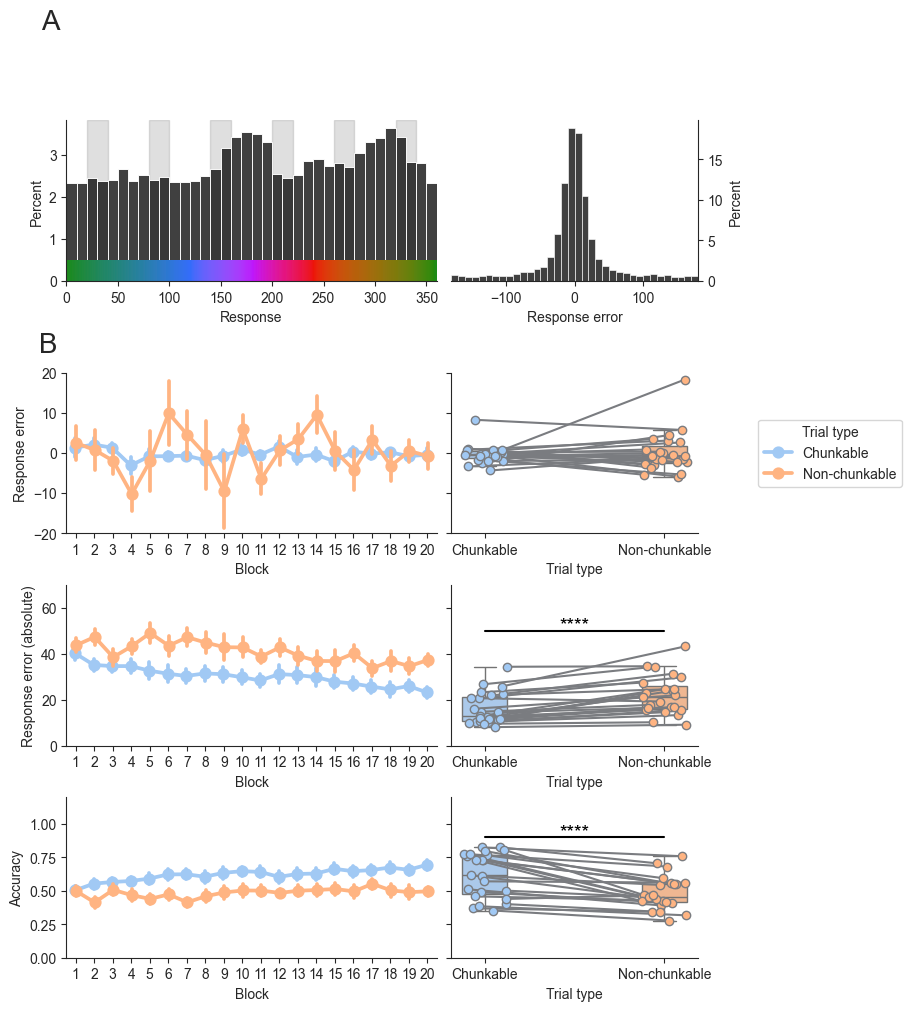

In [17]:
# Create the figure
fig,ax = pyplot.subplots(4,3,figsize=(9,10),constrained_layout=True,
                         gridspec_kw={'width_ratios':[1.5,1,0.4],'height_ratios':[1,1,1,1],
                                      'wspace':0,'hspace':0})
seaborn.set_style('ticks')
seaborn.despine()

# Ax0,0: average response distribution (non-locked)
forbiddenValues = [(20,40),(80,100),(140,160),(200,220),(260,280),(320,340)]
for xmin,xmax in forbiddenValues:
    ax[0,0].axvspan(xmin,xmax,color="grey",alpha=0.25,zorder=0,label=None)
seaborn.histplot(ax=ax[0,0],data=responseData,
                 x="Response",stat='percent',bins=nBinsHist,color='black')
for i in range(len(colourCircleValues)):
    ax[0,0].add_patch(patches.Rectangle((i,0),i+1,0.5,linewidth=0,facecolor=colourCircleValues[i]))
ax[0,0].set_xlim(0,360)
ax[0,0].text(-25,6,'A',fontsize=20)

# Ax0,1: average response distribution to the target (error distribution)
seaborn.histplot(ax=ax[0,1],data=allParticipantData,
                 x="Response error",stat='percent',bins=nBinsHist,color='black')
# ax[0,1].tick_params(axis='y',which='both',labelleft=False)
ax[0,1].yaxis.tick_right()
ax[0,1].yaxis.set_label_position('right')
ax[0,1].spines['left'].set_visible(False)
ax[0,1].spines['right'].set_visible(True)
ax[0,1].set_xlim(-180,180)
# ax[0,1].set_ylabel("")

# Ax1,0: effect of chunking over time on signed error
seaborn.pointplot(ax=ax[1,0],
                  data=errOverTime,
                  x='Block',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax[1,0].set_ylim(minBaseErrorOverBlocksValue,maxBaseErrorOverBlocksValue)
ax[1,0].text(-2,25,'B',fontsize=20)

# Ax1,1: effect of chunking over signed error
jlib.display.pairedObs.boxPlotPaired(ax=ax[1,1],
                                     data=errMean,
                                     x='Trial type',y='Response error',
                                     width=0.25,palette=paletteBase)
ax[1,1].set_ylim(minBaseErrorOverBlocksValue,maxBaseErrorOverBlocksValue)
ax[1,1].tick_params(axis='y',which='both',labelleft=False)
ax[1,1].set_ylabel("")

# Ax1,2: legend hotfix :)
handles,labels = ax[1,0].get_legend_handles_labels()
ax[1,2].legend(handles=handles,labels=labels,title='Trial type',loc='center left')
ax[1,0].legend().set_visible(False)
ax[1,2].axis('off')

# Ax2,0: effect of chunking over time on absolute error
seaborn.pointplot(ax=ax[2,0],
                  data=allParticipantData.groupby(['Subject','Block',
                                                   'Trial type']).mean().reset_index(),
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteBase)
ax[2,0].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)

# Ax2,1: effect of chunking over absolute error
jlib.display.pairedObs.boxPlotPaired(ax=ax[2,1],
                                     data=absErrData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax[2,1].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax[2,1].tick_params(axis='y',which='both',labelleft=False)
ax[2,1].set_ylabel("")
jlib.display.utils.displayPairwiseSignificance(ax[2,1],[0,1],50*numpy.array([1,1]),size=significanceSize,
                                               p=accChunkingTtestPS['ttest']['p'].to_numpy()[0])

# Ax3,0: effect of chunking over time on accuracy
seaborn.pointplot(ax=ax[3,0],
                  data=allParticipantData.groupby(['Subject','Block',
                                                   'Trial type']).mean().reset_index(),
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteBase)
ax[3,0].set_ylim(minAccuracyValue,maxAccuracyValue)

# Ax3,1: effect of chunking over time on accuracy
jlib.display.pairedObs.boxPlotPaired(ax=ax[3,1],
                                     data=accData,
                                     x='Trial type',y='Accuracy',
                                     width=0.25,palette=paletteBase)
ax[3,1].set_ylim(minAccuracyValue,maxAccuracyValue)
ax[3,1].tick_params(axis='y',which='both',labelleft=False)
ax[3,1].set_ylabel("")
jlib.display.utils.displayPairwiseSignificance(ax[3,1],[0,1],0.9*numpy.array([1,1]),size=significanceSize,
                                               p=accChunkingTtestPS['ttest']['p'].to_numpy()[0])

# More legend hotfixes
ax[0,2].axis('off')
ax[2,2].axis('off')
ax[3,2].axis('off')

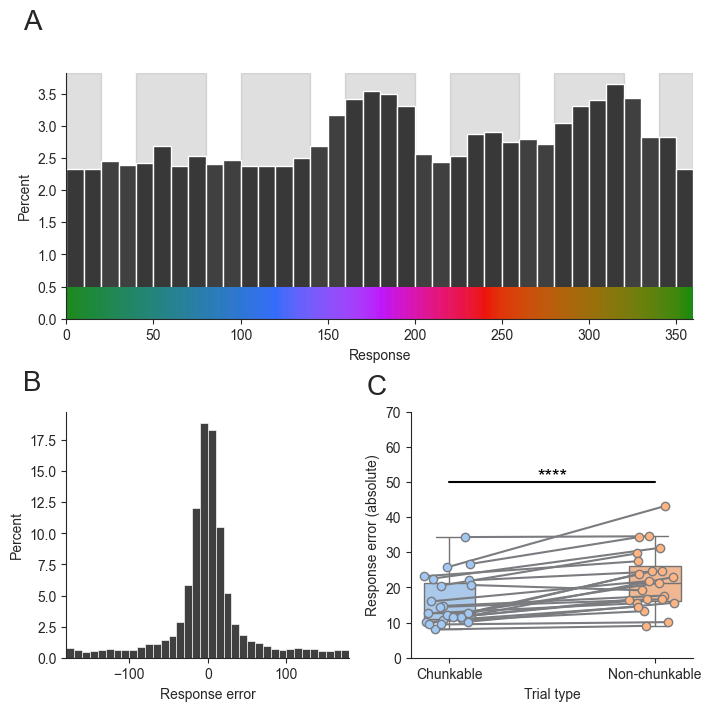

In [18]:
# Create the figure
fig,ax = pyplot.subplot_mosaic([['A','A'],['B','C']],figsize=(7,7),constrained_layout=True)
seaborn.set_style('ticks')
seaborn.despine()

# Ax0,0: average response distribution (non-locked)
forbiddenValues = [(0,20),(40,80),(100,140),(160,200),(220,260),(280,320),(340,360)]
for xmin,xmax in forbiddenValues:
    ax['A'].axvspan(xmin,xmax,color="grey",alpha=0.25,zorder=0,label=None)
seaborn.histplot(ax=ax['A'],data=responseData,
                 x="Response",stat='percent',bins=nBinsHist,color='black')
for i in range(len(colourCircleValues)):
    ax['A'].add_patch(patches.Rectangle((i,0),i+1,0.5,linewidth=0,facecolor=colourCircleValues[i]))
ax['A'].set_xlim(0,360)
ax['A'].text(-25,4.5,'A',fontsize=20)

# Ax1,0: average response distribution to the target (error distribution)
seaborn.histplot(ax=ax['B'],data=allParticipantData,
                 x="Response error",stat='percent',bins=nBinsHist,color='black')
ax['B'].set_xlim(-180,180)
ax['B'].text(-235,21.5,'B',fontsize=20)

# Ax1,1: effect of chunking over absolute error
jlib.display.pairedObs.boxPlotPaired(ax=ax['C'],
                                     data=absErrData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax['C'].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax['C'].text(-0.4,75,'C',fontsize=20)
jlib.display.utils.displayPairwiseSignificance(ax['C'],[0,1],50*numpy.array([1,1]),size=significanceSize,
                                               p=accChunkingTtestPS['ttest']['p'].to_numpy()[0])

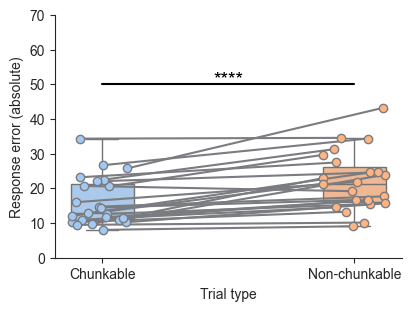

In [19]:
fig,ax = pyplot.subplots(figsize=(4,3),constrained_layout=True)
seaborn.set_style('ticks')
seaborn.despine()

# Ax1,1: effect of chunking over absolute error
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=absErrData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax.set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],50*numpy.array([1,1]),size=significanceSize,
                                               p=absErrChunkingTtestPS['ttest']['p'].to_numpy()[0])

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'responseAndChunking.'+format,format=format,dpi=1200)